In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv('bank_data_cleaned.csv')

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8949 entries, 0 to 8948
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8949 non-null   float64
 1   BALANCE_FREQUENCY                 8949 non-null   float64
 2   PURCHASES                         8949 non-null   float64
 3   ONEOFF_PURCHASES                  8949 non-null   float64
 4   INSTALLMENTS_PURCHASES            8949 non-null   float64
 5   CASH_ADVANCE                      8949 non-null   float64
 6   PURCHASES_FREQUENCY               8949 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8949 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8949 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8949 non-null   float64
 10  CASH_ADVANCE_TRX                  8949 non-null   int64  
 11  PURCHASES_TRX                     8949 non-null   int64  
 12  CREDIT_LIMIT     

In [3]:
features = [
    "BALANCE_FREQUENCY",
    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",
    "PURCHASES",
    "CASH_ADVANCE_TRX"
]
X = df[features]

In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

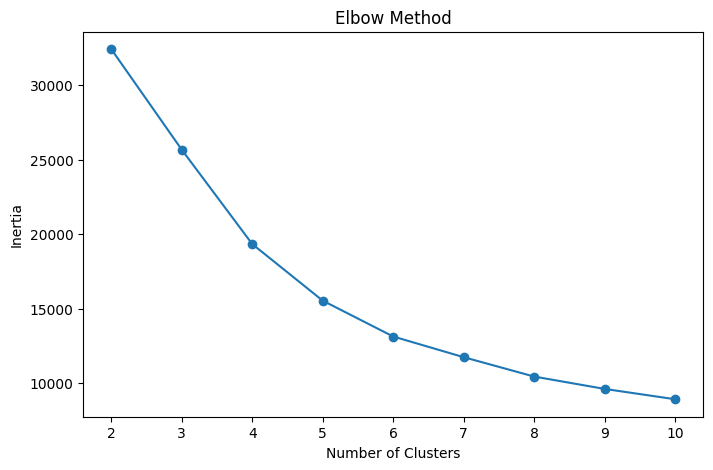

Clusters: 2, Silhouette Score: 0.3548
Clusters: 3, Silhouette Score: 0.4057
Clusters: 4, Silhouette Score: 0.4346
Clusters: 5, Silhouette Score: 0.4493
Clusters: 6, Silhouette Score: 0.4507
Clusters: 7, Silhouette Score: 0.4313
Clusters: 8, Silhouette Score: 0.4273
Clusters: 9, Silhouette Score: 0.4140
Clusters: 10, Silhouette Score: 0.3908

Selected number of clusters: 6


In [5]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_data)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

for k, score in zip(K_range, silhouette_scores):
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nSelected number of clusters: {best_k}")


In [6]:
#Although k=6 gave the highest silhouette score, k=4 (or 5) was selected for better interpretability.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_data)

In [7]:
cluster_analysis = df.groupby("Cluster")[features].mean()
print(cluster_analysis)


         BALANCE_FREQUENCY  PURCHASES_FREQUENCY  PURCHASES_TRX    PURCHASES  \
Cluster                                                                       
0                 0.970129             0.121506       2.165986   204.660554   
1                 0.989324             0.961209     100.457766  7795.153215   
2                 0.967612             0.862160      21.698689  1315.409034   
3                 0.385853             0.280492       4.426253   353.283056   

         CASH_ADVANCE_TRX  
Cluster                    
0                6.071762  
1                2.855586  
2                1.580145  
3                0.923783  


The clustering results reveal clear differences in customer activity levels. Cluster 1 represents highly active customers, with very high purchase frequency, transaction counts, and total spending. Cluster 2 includes active customers who use the service regularly, but at a lower intensity compared to Cluster 1.


Cluster 0 represents low-activity customers with minimal purchasing behaviour but the highest use of cash advances, indicating a reliance on credit rather than regular spending. Cluster 3 consists of the most passive customers, showing consistently low activity across all variables and the lowest engagement overall.


Overall, the clusters represent distinct levels of customer engagement, ranging from highly active users to low-engagement and credit-reliant customers.

In [8]:
cluster_names = {
    0: "Passive Credit Users",
    1: "Highly Active Users",
    2: "Active Users",
    3: "Passive Low Users"
}

df["Segment_Name"] = df["Cluster"].map(cluster_names)


In [9]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

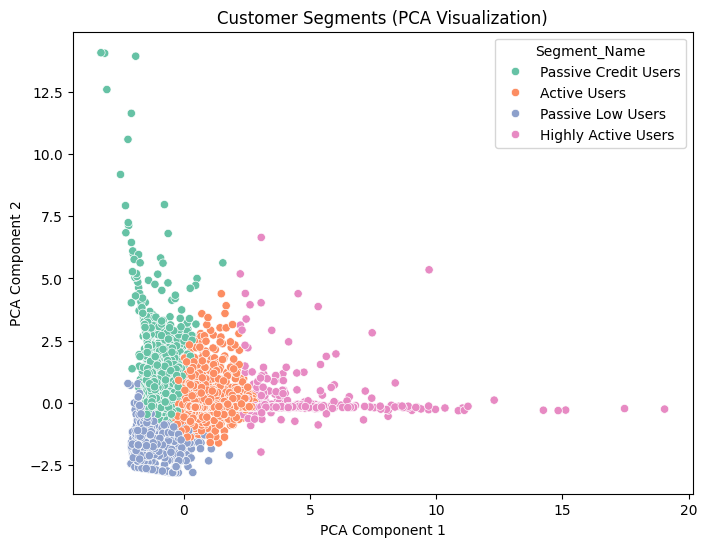

In [10]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Segment_Name",
    data=df,
    palette="Set2"
)

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

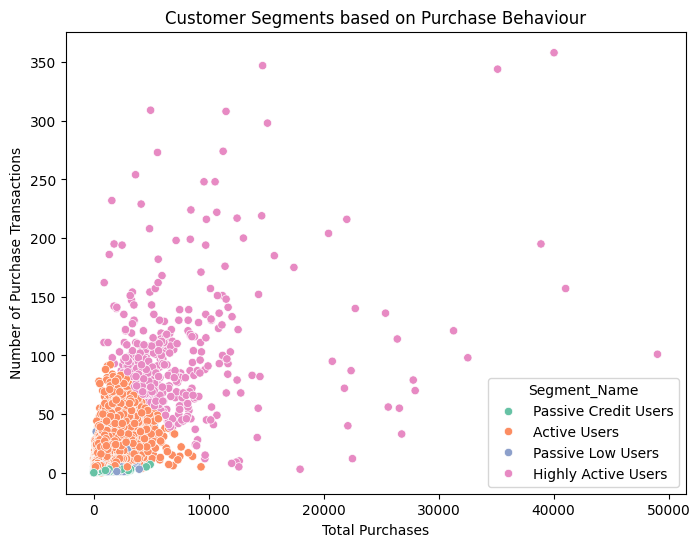

In [11]:
# Scatter plot: Purchase Behaviour
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PURCHASES",
    y="PURCHASES_TRX",
    hue="Segment_Name",
    palette="Set2"
)
plt.title("Customer Segments based on Purchase Behaviour")
plt.xlabel("Total Purchases")
plt.ylabel("Number of Purchase Transactions")
plt.show()

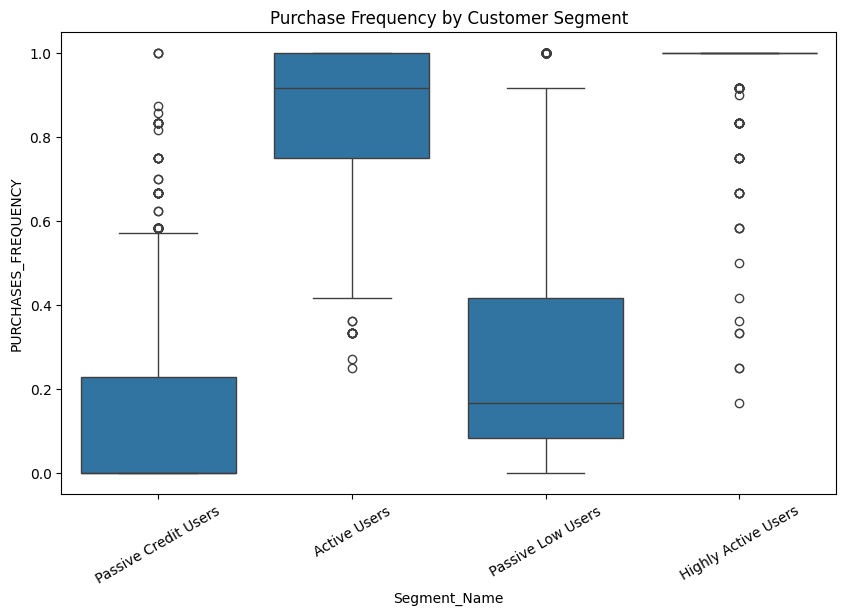

In [12]:
# Boxplot: Purchase Frequency
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Segment_Name",
    y="PURCHASES_FREQUENCY"
)
plt.title("Purchase Frequency by Customer Segment")
plt.xticks(rotation=30)
plt.show()

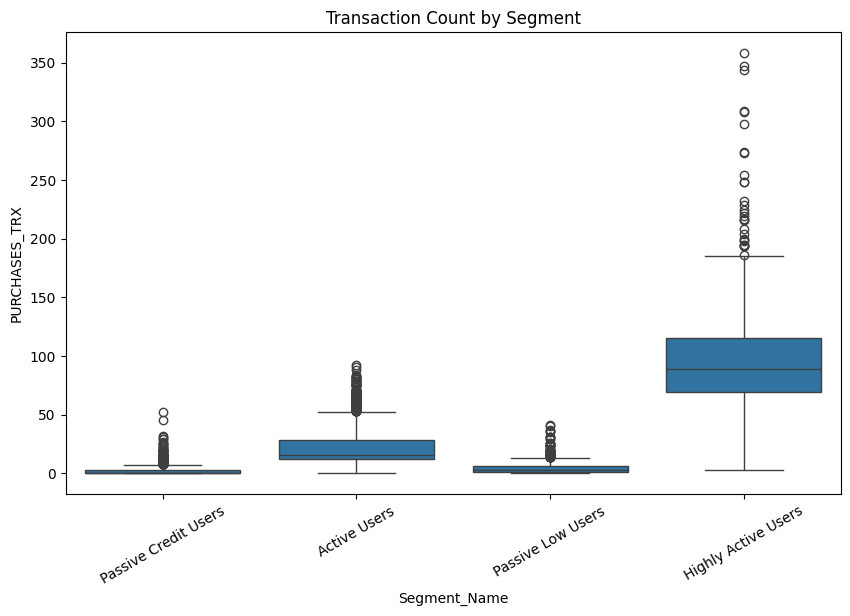

In [13]:
# Boxplot: Transactions
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Segment_Name",
    y="PURCHASES_TRX"
)
plt.title("Transaction Count by Segment")
plt.xticks(rotation=30)
plt.show()

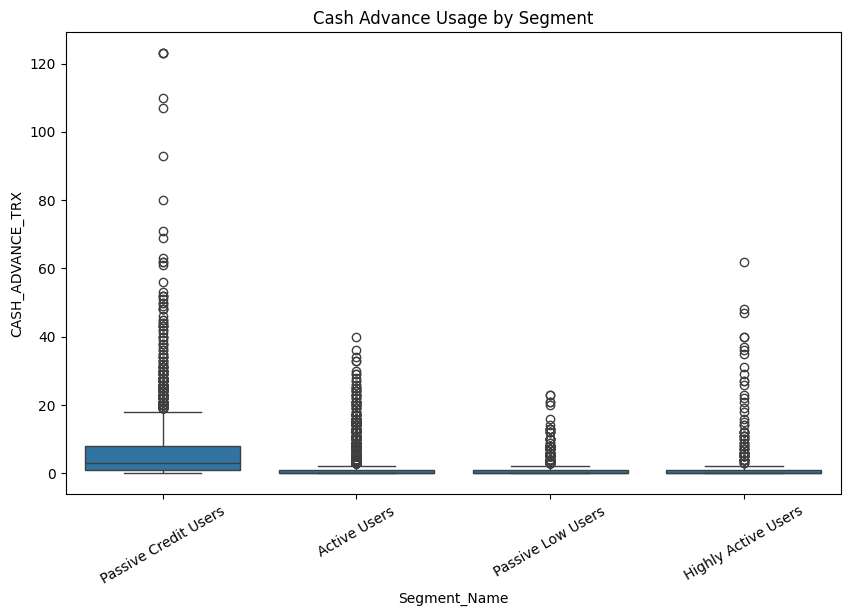

In [14]:
# Boxplot: Cash Advance
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Segment_Name",
    y="CASH_ADVANCE_TRX"
)
plt.title("Cash Advance Usage by Segment")
plt.xticks(rotation=30)
plt.show()

C:\Users\Fredrika\AppData\Local\Temp\ipykernel_31484\1886579891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


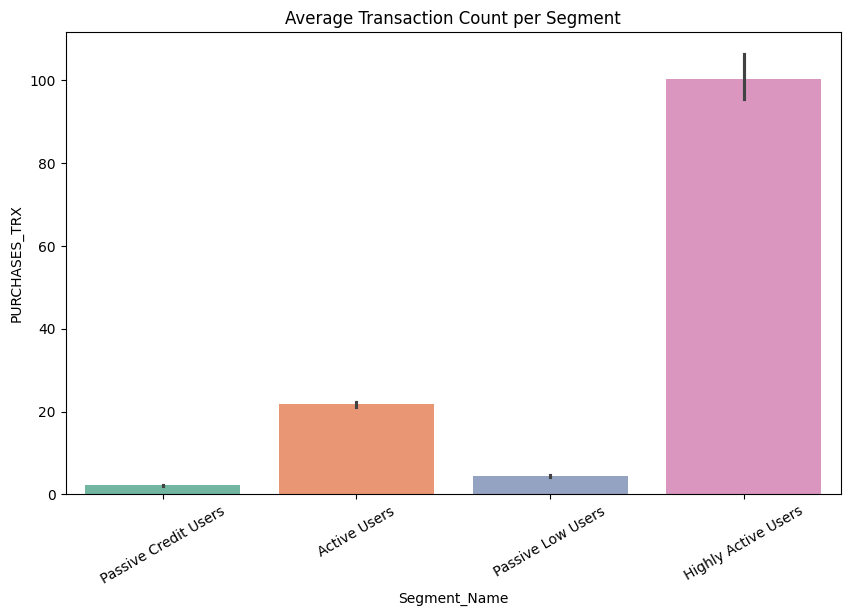

In [15]:
# Shows average transactions per segment.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x="Segment_Name",
    y="PURCHASES_TRX",
    estimator="mean",
    palette="Set2"
)

plt.title("Average Transaction Count per Segment")
plt.xticks(rotation=30)
plt.show()


C:\Users\Fredrika\AppData\Local\Temp\ipykernel_31484\703982108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


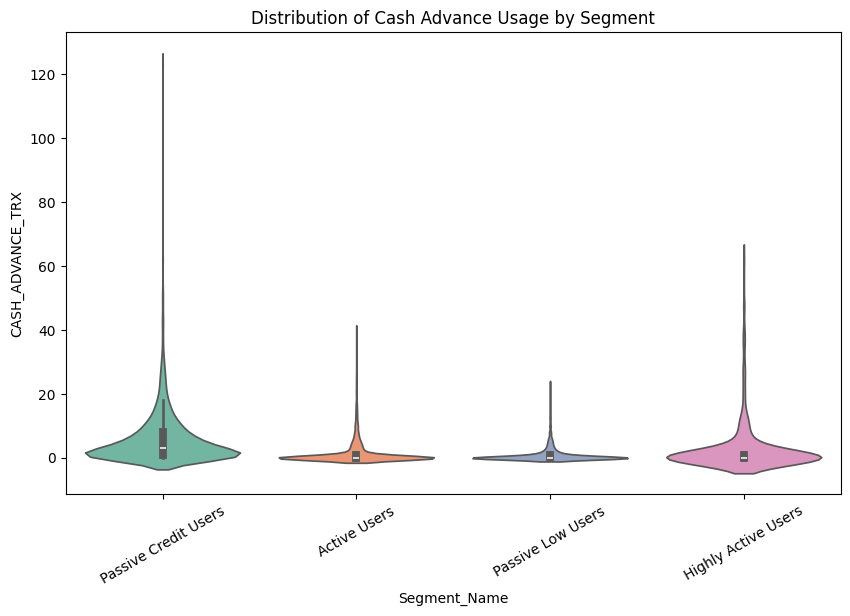

In [16]:
# Shows variation in cash advance usage across segments.
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Segment_Name",
    y="CASH_ADVANCE_TRX",
    palette="Set2"
)

plt.title("Distribution of Cash Advance Usage by Segment")
plt.xticks(rotation=30)
plt.show()


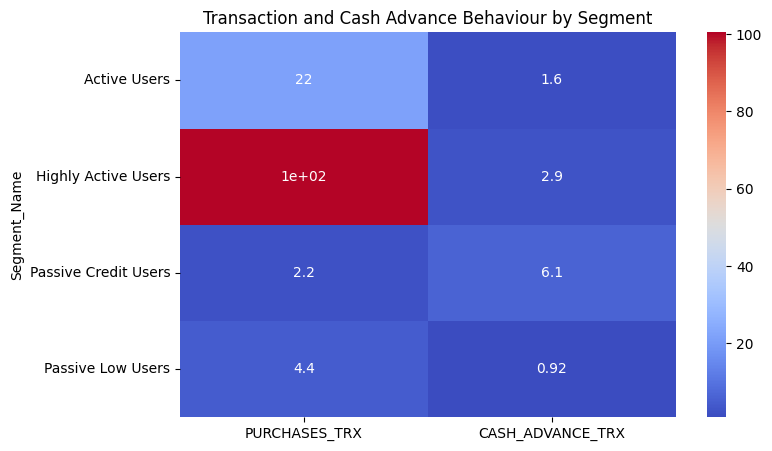

In [17]:
# Compares transaction and credit behaviour between segments.
cluster_means = df.groupby("Segment_Name")[[
    "PURCHASES_TRX",
    "CASH_ADVANCE_TRX"
]].mean()

plt.figure(figsize=(8, 5))
sns.heatmap(cluster_means, annot=True, cmap="coolwarm")

plt.title("Transaction and Cash Advance Behaviour by Segment")
plt.show()


In [18]:
df.to_csv("bank_data_with_clusters.csv", index=False)

In [19]:
df.to_excel("bank_data_with_clusters.xlsx", index=False)